In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [2]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

model_data_path = (
    project_root
    / "data"
    / "processed"
    / "methane_forecasting_features_2024.parquet"
)

model_df = pd.read_parquet(model_data_path)

model_df = (
    model_df
    .sort_values(["week", "cell_id"])
    .reset_index(drop=True)
)

In [3]:
unique_weeks = np.sort(
    model_df["week"].unique()
)

test_fraction = 0.20

split_index = int(
    len(unique_weeks) * (1 - test_fraction)
)

train_weeks = unique_weeks[:split_index]
test_weeks = unique_weeks[split_index:]

train_df = model_df[
    model_df["week"].isin(train_weeks)
].copy()

test_df = model_df[
    model_df["week"].isin(test_weeks)
].copy()

In [10]:
print("Training period:")
print(train_df["week"].min(), "→", train_df["week"].max())

print("\nTest period:")
print(test_df["week"].min(), "→", test_df["week"].max())

print("\nTraining rows:", len(train_df))
print("Test rows:", len(test_df))
print("Test weeks:", len(test_weeks))

Training period:
2024-01-14 00:00:00 → 2024-10-20 00:00:00

Test period:
2024-10-27 00:00:00 → 2024-12-22 00:00:00

Training rows: 23689
Test rows: 3609
Test weeks: 9


In [4]:
y_test = test_df["target_next_week"]

persistence_predictions = test_df["CH4"]

In [14]:
persistence_errors = (
    y_test - persistence_predictions
)

persistence_mean_error = persistence_errors.mean()

persistence_mae = mean_absolute_error(
    y_test,
    persistence_predictions,
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        persistence_predictions,
    )
)

persistence_r2 = r2_score(
    y_test,
    persistence_predictions,
)

print(
    f"Mean error: {persistence_mean_error:.3f} ppb"
)
print(
    f"Persistence MAE: {persistence_mae:.3f} ppb"
)
print(
    f"Persistence RMSE: {persistence_rmse:.3f} ppb"
)
print(
    f"Persistence R²: {persistence_r2:.3f}"
)

Mean error: 0.519 ppb
Persistence MAE: 14.422 ppb
Persistence RMSE: 17.889 ppb
Persistence R²: -0.349


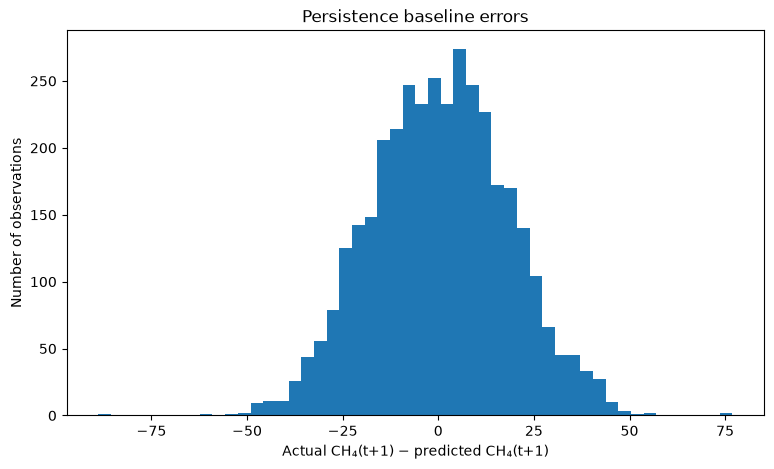

In [14]:
persistence_errors.plot.hist(
    bins=50,
    figsize=(9, 5),
)

plt.title("Persistence baseline errors")
plt.xlabel("Actual CH₄(t+1) − predicted CH₄(t+1)")
plt.ylabel("Number of observations")
plt.show()

In [15]:
weekly_baseline_errors = (
    test_df
    .assign(
        persistence_error=persistence_errors
    )
    .groupby("week", as_index=False)
    .agg(
        mean_error=("persistence_error", "mean"),
        mae=(
            "persistence_error",
            lambda values: values.abs().mean(),
        ),
    )
)

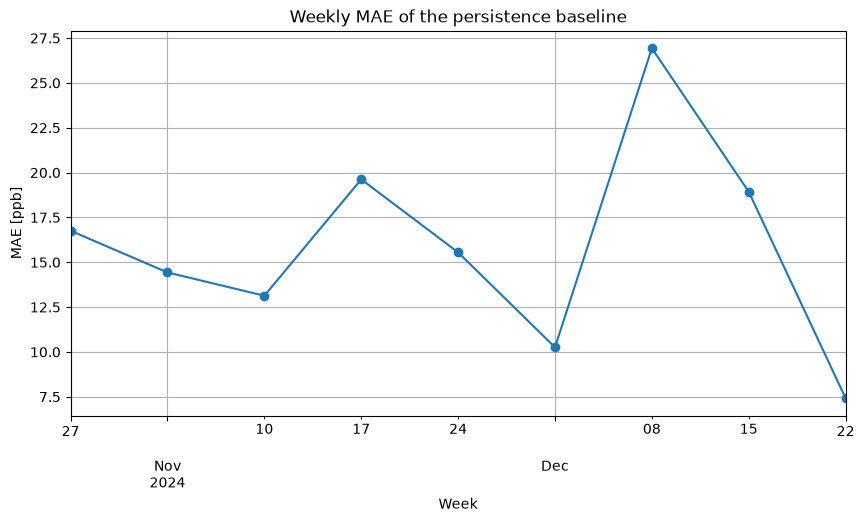

In [16]:
weekly_baseline_errors.plot(
    x="week",
    y="mae",
    figsize=(10, 5),
    marker="o",
    legend=False,
)

plt.title("Weekly MAE of the persistence baseline")
plt.xlabel("Week")
plt.ylabel("MAE [ppb]")
plt.grid()
plt.show()

In [5]:
feature_columns = [
    "CH4",
    "ch4_prev_1w",
    "ch4_prev_2w",
    "ch4_change_1w",
    "ch4_mean_last_3w",
    "ch4_std_last_3w",
    "x",
    "y",
    "season_sin",
    "season_cos",
]

target_column = "target_next_week"

In [6]:
X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

In [9]:
assert not X_train.isna().any().any()
assert not X_test.isna().any().any()
assert not y_train.isna().any()
assert not y_test.isna().any()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (23689, 10)
X_test shape: (3609, 10)


In [20]:
ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0),
)

In [ ]:
ridge_model.fit(X_train, y_train)

In [22]:
ridge_predictions = ridge_model.predict(X_test)

In [23]:
ridge_errors = y_test - ridge_predictions

ridge_mean_error = ridge_errors.mean()

ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions,
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions,
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions,
)

print(f"Mean error: {ridge_mean_error:.3f} ppb")
print(f"Ridge MAE: {ridge_mae:.3f} ppb")
print(f"Ridge RMSE: {ridge_rmse:.3f} ppb")
print(f"Ridge R²: {ridge_r2:.3f}")

Mean error: 12.200 ppb
Ridge MAE: 16.219 ppb
Ridge RMSE: 19.298 ppb
Ridge R²: -0.570


In [16]:
results_df = pd.DataFrame({
    "model": [
        "Persistence",
        "Ridge",
    ],
    "MAE": [
        persistence_mae,
        ridge_mae,
    ],
    "RMSE": [
        persistence_rmse,
        ridge_rmse,
    ],
    "R2": [
        persistence_r2,
        ridge_r2,
    ],
})

results_df

,model,MAE,RMSE,R2
0,Persistence,14.422291,17.888740,-0.34875
1,Ridge,16.219157,19.298327,-0.56968


In [24]:
ridge_mae_improvement = (
    persistence_mae - ridge_mae
) / persistence_mae * 100

print(
    f"MAE improvement over persistence: "
    f"{ridge_mae_improvement:.2f}%"
)

MAE improvement over persistence: -12.46%


In [18]:
ridge_estimator = ridge_model.named_steps["ridge"]

In [ ]:
ridge_coefficients = (
    pd.DataFrame({
        "feature": feature_columns,
        "coefficient": ridge_estimator.coef_,
    })
    .assign(
        absolute_coefficient=lambda df: (
            df["coefficient"].abs()
        )
    )
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
)

ridge_coefficients

In [ ]:
ridge_coefficients.plot.barh(
    x="feature",
    y="coefficient",
    figsize=(9, 6),
    legend=False,
)

plt.title("Standardized Ridge coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

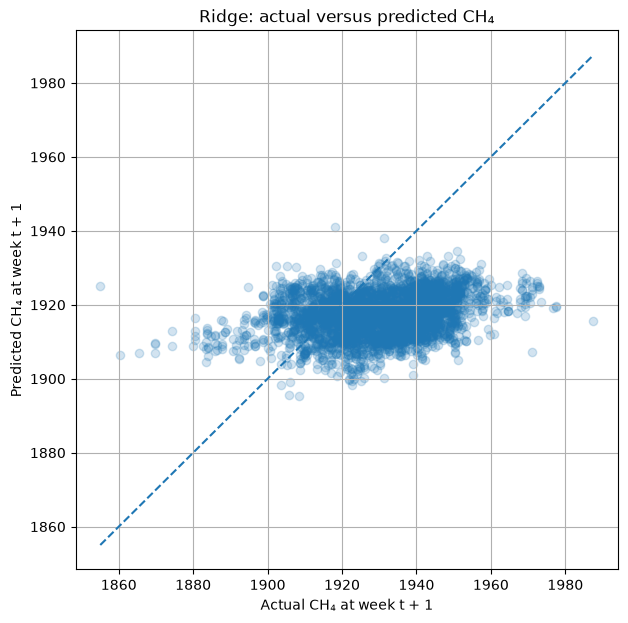

In [21]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    ridge_predictions,
    alpha=0.2,
)

lower = min(
    y_test.min(),
    ridge_predictions.min(),
)

upper = max(
    y_test.max(),
    ridge_predictions.max(),
)

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
)

plt.title("Ridge: actual versus predicted CH₄")
plt.xlabel("Actual CH₄ at week t + 1")
plt.ylabel("Predicted CH₄ at week t + 1")
plt.grid()
plt.show()

In [ ]:
print("Mean training target:", y_train.mean())
print("Mean test target:", y_test.mean())
print("Mean Ridge prediction:", ridge_predictions.mean())

print("Training target range:")
print(y_train.min(), y_train.max())

print("Test target range:")
print(y_test.min(), y_test.max())

In [26]:
print("Test target standard deviation:", y_test.std())
print("Ridge prediction standard deviation:", ridge_predictions.std())

print(
    "Prediction-target correlation:",
    np.corrcoef(y_test, ridge_predictions)[0, 1],
)

Test target standard deviation: 15.405445
Ridge prediction standard deviation: 5.819537417005223
Prediction-target correlation: 0.265235932714487


In [8]:
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)

In [9]:
random_forest_model.fit(
    X_train,
    y_train,
)

rf_predictions = random_forest_model.predict(
    X_test
)

In [12]:
rf_errors = y_test - rf_predictions

rf_mean_error = rf_errors.mean()

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions,
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions,
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions,
)

print(f"Mean error: {rf_mean_error:.3f} ppb")
print(f"Random Forest MAE: {rf_mae:.3f} ppb")
print(f"Random Forest RMSE: {rf_rmse:.3f} ppb")
print(f"Random Forest R²: {rf_r2:.3f}")

Mean error: 8.787 ppb
Random Forest MAE: 12.828 ppb
Random Forest RMSE: 15.800 ppb
Random Forest R²: -0.052


In [15]:
rf_mae_improvement = (
    persistence_mae - rf_mae
) / persistence_mae * 100

print(
    f"MAE improvement over persistence: "
    f"{rf_mae_improvement:.2f}%"
)

MAE improvement over persistence: 11.05%


In [ ]:
print(
    "Mean test target:",
    y_test.mean(),
)

print(
    "Mean Random Forest prediction:",
    rf_predictions.mean(),
)

print(
    "Test target standard deviation:",
    y_test.std(),
)

print(
    "Random Forest prediction standard deviation:",
    rf_predictions.std(),
)

print(
    "Prediction-target correlation:",
    np.corrcoef(
        y_test,
        rf_predictions,
    )[0, 1],
)

In [17]:
rf_train_predictions = random_forest_model.predict(
    X_train
)

rf_train_mae = mean_absolute_error(
    y_train,
    rf_train_predictions,
)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        rf_train_predictions,
    )
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_predictions,
)

print(f"Training MAE: {rf_train_mae:.3f} ppb")
print(f"Training RMSE: {rf_train_rmse:.3f} ppb")
print(f"Training R²: {rf_train_r2:.3f}")

print(f"\nTest MAE: {rf_mae:.3f} ppb")
print(f"Test RMSE: {rf_rmse:.3f} ppb")
print(f"Test R²: {rf_r2:.3f}")

Training MAE: 2.229 ppb
Training RMSE: 3.166 ppb
Training R²: 0.979

Test MAE: 12.828 ppb
Test RMSE: 15.800 ppb
Test R²: -0.052


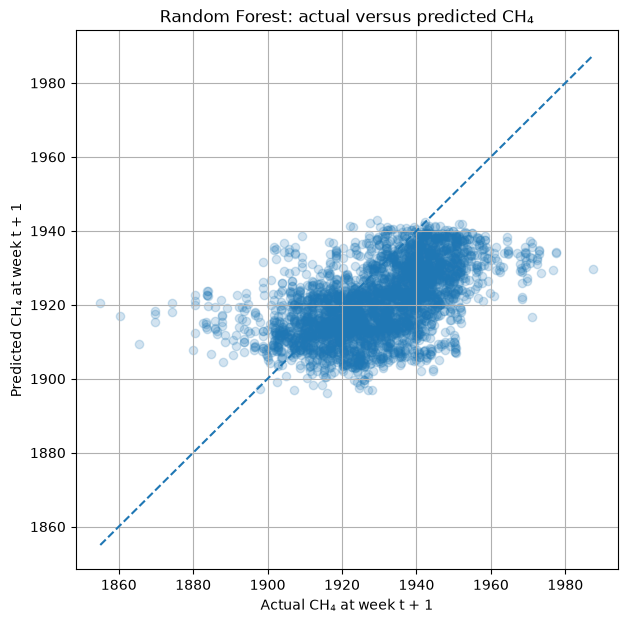

In [18]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.2,
)

lower = min(
    y_test.min(),
    rf_predictions.min(),
)

upper = max(
    y_test.max(),
    rf_predictions.max(),
)

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
)

plt.title(
    "Random Forest: actual versus predicted CH₄"
)
plt.xlabel("Actual CH₄ at week t + 1")
plt.ylabel("Predicted CH₄ at week t + 1")
plt.grid()
plt.show()

In [25]:
rf_weekly_comparison = (
    test_df
    .assign(
        rf_prediction=rf_predictions,
        persistence_prediction=persistence_predictions.values,
        ridge_prediction=ridge_predictions,
    )
    .groupby("week", as_index=False)
    .agg(
        actual_ch4=(
            "target_next_week",
            "mean",
        ),
        persistence_prediction=(
            "persistence_prediction",
            "mean",
        ),
        ridge_prediction=(
            "ridge_prediction",
            "mean",
        ),
        rf_prediction=(
            "rf_prediction",
            "mean",
        ),
    )
)

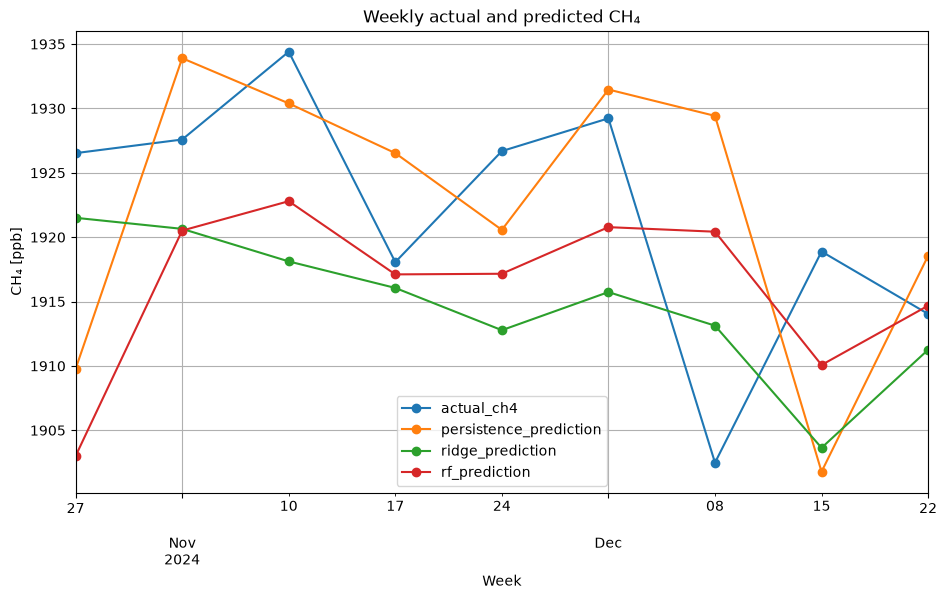

In [26]:
rf_weekly_comparison.plot(
    x="week",
    y=[
        "actual_ch4",
        "persistence_prediction",
        "ridge_prediction",
        "rf_prediction",
    ],
    figsize=(11, 6),
    marker="o",
)

plt.title(
    "Weekly actual and predicted CH₄"
)
plt.xlabel("Week")
plt.ylabel("CH₄ [ppb]")
plt.grid()
plt.show()

In [27]:
results_df = pd.DataFrame({
    "model": [
        "Persistence",
        "Ridge",
        "Random Forest",
    ],
    "mean_error": [
        persistence_mean_error,
        ridge_mean_error,
        rf_mean_error,
    ],
    "MAE": [
        persistence_mae,
        ridge_mae,
        rf_mae,
    ],
    "RMSE": [
        persistence_rmse,
        ridge_rmse,
        rf_rmse,
    ],
    "R2": [
        persistence_r2,
        ridge_r2,
        rf_r2,
    ],
})

results_df

,model,mean_error,MAE,RMSE,R2
0,Persistence,0.518766,14.422291,17.888740,-0.348750
1,Ridge,12.200329,16.219157,19.298327,-0.569680
2,Random Forest,8.787158,12.828155,15.799858,-0.052151


In [ ]:
rf_feature_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "importance": (
            random_forest_model.feature_importances_
        ),
    })
    .sort_values(
        "importance",
        ascending=False,
    )
)

rf_feature_importance

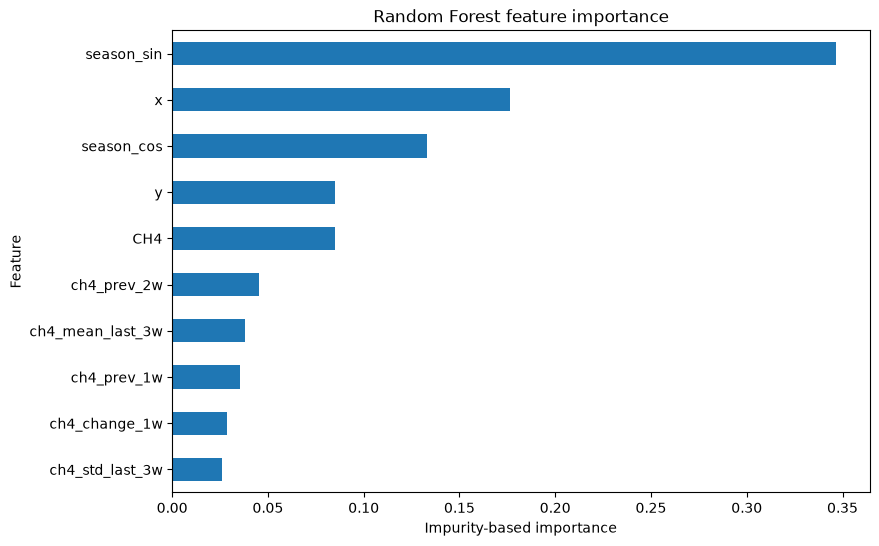

In [29]:
rf_feature_importance.plot.barh(
    x="feature",
    y="importance",
    figsize=(9, 6),
    legend=False,
)

plt.title(
    "Random Forest feature importance"
)
plt.xlabel("Impurity-based importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [30]:
inner_weeks = np.sort(train_df["week"].unique())

validation_fraction = 0.20
validation_start = int(
    len(inner_weeks) * (1 - validation_fraction)
)

fit_weeks = inner_weeks[:validation_start]
validation_weeks = inner_weeks[validation_start:]

fit_df = train_df[
    train_df["week"].isin(fit_weeks)
].copy()

validation_df = train_df[
    train_df["week"].isin(validation_weeks)
].copy()

X_fit = fit_df[feature_columns]
y_fit = fit_df[target_column]

X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]

print(
    "Inner training:",
    fit_df["week"].min(),
    "→",
    fit_df["week"].max(),
)

print(
    "Validation:",
    validation_df["week"].min(),
    "→",
    validation_df["week"].max(),
)

assert fit_df["week"].max() < validation_df["week"].min()

Inner training: 2024-01-14 00:00:00 → 2024-08-25 00:00:00
Validation: 2024-09-01 00:00:00 → 2024-10-20 00:00:00


In [31]:
rf_configurations = [
    {
        "name": "Default-like",
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": 1.0,
        "max_samples": None,
    },
    {
        "name": "Moderately regularized",
        "max_depth": 12,
        "min_samples_leaf": 10,
        "max_features": 0.7,
        "max_samples": 0.8,
    },
    {
        "name": "Strongly regularized",
        "max_depth": 8,
        "min_samples_leaf": 20,
        "max_features": 0.7,
        "max_samples": 0.8,
    },
    {
        "name": "Large leaves",
        "max_depth": None,
        "min_samples_leaf": 25,
        "max_features": "sqrt",
        "max_samples": 0.8,
    },
]

In [32]:
validation_results = []

for config in rf_configurations:
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        max_samples=config["max_samples"],
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_fit, y_fit)

    fit_predictions = model.predict(X_fit)
    validation_predictions = model.predict(X_validation)

    validation_results.append({
        "model": config["name"],
        "train_MAE": mean_absolute_error(
            y_fit,
            fit_predictions,
        ),
        "validation_MAE": mean_absolute_error(
            y_validation,
            validation_predictions,
        ),
        "validation_RMSE": np.sqrt(
            mean_squared_error(
                y_validation,
                validation_predictions,
            )
        ),
        "validation_R2": r2_score(
            y_validation,
            validation_predictions,
        ),
    })

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values("validation_MAE")
    .reset_index(drop=True)
)

validation_results_df

,model,train_MAE,validation_MAE,validation_RMSE,validation_R2
0,Large leaves,7.778371,14.673968,17.917496,-0.514506
1,Strongly regularized,8.077320,17.295189,20.967299,-1.073965
2,Moderately regularized,6.367700,17.888172,21.907265,-1.264085
3,Default-like,2.196655,19.713783,24.567352,-1.847299


In [33]:
validation_persistence_predictions = validation_df["CH4"]

validation_persistence_mae = mean_absolute_error(
    y_validation,
    validation_persistence_predictions,
)

validation_persistence_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        validation_persistence_predictions,
    )
)

validation_persistence_r2 = r2_score(
    y_validation,
    validation_persistence_predictions,
)

print(
    f"Validation persistence MAE: "
    f"{validation_persistence_mae:.3f} ppb"
)
print(
    f"Validation persistence RMSE: "
    f"{validation_persistence_rmse:.3f} ppb"
)
print(
    f"Validation persistence R²: "
    f"{validation_persistence_r2:.3f}"
)

Validation persistence MAE: 16.439 ppb
Validation persistence RMSE: 21.774 ppb
Validation persistence R²: -1.237


In [34]:
selected_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=25,
    max_features="sqrt",
    max_samples=0.8,
    random_state=42,
    n_jobs=-1,
)

In [35]:
selected_rf_model.fit(X_train, y_train)

selected_rf_predictions = selected_rf_model.predict(X_test)

In [36]:
selected_rf_errors = y_test - selected_rf_predictions

selected_rf_mean_error = selected_rf_errors.mean()

selected_rf_mae = mean_absolute_error(
    y_test,
    selected_rf_predictions,
)

selected_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        selected_rf_predictions,
    )
)

selected_rf_r2 = r2_score(
    y_test,
    selected_rf_predictions,
)

print(
    f"Mean error: {selected_rf_mean_error:.3f} ppb"
)
print(
    f"Selected Random Forest MAE: "
    f"{selected_rf_mae:.3f} ppb"
)
print(
    f"Selected Random Forest RMSE: "
    f"{selected_rf_rmse:.3f} ppb"
)
print(
    f"Selected Random Forest R²: "
    f"{selected_rf_r2:.3f}"
)

Mean error: 9.452 ppb
Selected Random Forest MAE: 14.051 ppb
Selected Random Forest RMSE: 16.919 ppb
Selected Random Forest R²: -0.206


In [37]:
print(
    "Mean test target:",
    y_test.mean(),
)

print(
    "Mean selected RF prediction:",
    selected_rf_predictions.mean(),
)

print(
    "Test target standard deviation:",
    y_test.std(),
)

print(
    "Selected RF prediction standard deviation:",
    selected_rf_predictions.std(),
)

print(
    "Prediction-target correlation:",
    np.corrcoef(
        y_test,
        selected_rf_predictions,
    )[0, 1],
)

Mean test target: 1929.5707
Mean selected RF prediction: 1920.1184384604132
Test target standard deviation: 15.405445
Selected RF prediction standard deviation: 7.178505993211249
Prediction-target correlation: 0.4155424624397036


In [38]:
selected_rf_train_predictions = (
    selected_rf_model.predict(X_train)
)

selected_rf_train_mae = mean_absolute_error(
    y_train,
    selected_rf_train_predictions,
)

selected_rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        selected_rf_train_predictions,
    )
)

selected_rf_train_r2 = r2_score(
    y_train,
    selected_rf_train_predictions,
)

print("Selected Random Forest")
print("----------------------")
print(
    f"Training MAE: {selected_rf_train_mae:.3f} ppb"
)
print(
    f"Training RMSE: {selected_rf_train_rmse:.3f} ppb"
)
print(
    f"Training R²: {selected_rf_train_r2:.3f}"
)

print(
    f"\nTest MAE: {selected_rf_mae:.3f} ppb"
)
print(
    f"Test RMSE: {selected_rf_rmse:.3f} ppb"
)
print(
    f"Test R²: {selected_rf_r2:.3f}"
)

Selected Random Forest
----------------------
Training MAE: 7.878 ppb
Training RMSE: 10.789 ppb
Training R²: 0.754

Test MAE: 14.051 ppb
Test RMSE: 16.919 ppb
Test R²: -0.206


In [39]:
final_results_df = pd.DataFrame({
    "model": [
        "Persistence",
        "Ridge",
        "Random Forest — default",
        "Random Forest — regularized",
    ],
    "mean_error": [
        persistence_mean_error,
        ridge_mean_error,
        rf_mean_error,
        selected_rf_mean_error,
    ],
    "MAE": [
        persistence_mae,
        ridge_mae,
        rf_mae,
        selected_rf_mae,
    ],
    "RMSE": [
        persistence_rmse,
        ridge_rmse,
        rf_rmse,
        selected_rf_rmse,
    ],
    "R2": [
        persistence_r2,
        ridge_r2,
        rf_r2,
        selected_rf_r2,
    ],
})

final_results_df.sort_values("MAE")

,model,mean_error,MAE,RMSE,R2
2,Random Forest — default,8.787158,12.828155,15.799858,-0.052151
3,Random Forest — regularized,9.452260,14.051327,16.918711,-0.206442
0,Persistence,0.518766,14.422291,17.888740,-0.348750
1,Ridge,12.200329,16.219157,19.298327,-0.569680
